# Notebook 05 — Crisis Prediction Model Training
**Dissertation: Economic Crisis Prediction — Interpretability vs Statistical Accuracy**

This notebook trains and evaluates four models on the JST+Sentiment master dataset:
- Logistic Regression (baseline — high interpretability)
- Random Forest (ensemble — moderate interpretability)
- XGBoost (boosting — moderate interpretability)
- SHAP Analysis (post-hoc interpretability layer)

Input:  `data/processed/jst_sentiment_master.csv`  
Output: `data/processed/model_results.csv`, `data/processed/shap_values.csv`

## Cell 1 — Imports and Configuration

In [1]:
import os
os.environ['PYTHONWARNINGS'] = 'ignore'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    RocCurveDisplay
)
from sklearn.pipeline import Pipeline
import xgboost as xgb
import shap

# Paths
BASE         = Path(r'C:\Users\Owner\OneDrive\dissertation')
DATA_IN      = BASE / 'data' / 'processed' / 'jst_sentiment_master.csv'
OUT_DIR      = BASE / 'data' / 'processed'
FIG_DIR      = BASE / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42
CV_FOLDS     = 5

# Check input file
assert DATA_IN.exists(), f'Input file not found: {DATA_IN}'
print('=' * 60)
print(' CRISIS PREDICTION MODEL TRAINING')
print('=' * 60)
print(f'Input   : {DATA_IN}')
print(f'Figures : {FIG_DIR}')
print(f'CV folds: {CV_FOLDS}')

# Confirm package versions
print(f'\nnumpy   : {np.__version__}')
print(f'xgboost : {xgb.__version__}')
print(f'shap    : {shap.__version__}')

 CRISIS PREDICTION MODEL TRAINING
Input   : C:\Users\Owner\OneDrive\dissertation\data\processed\jst_sentiment_master.csv
Figures : C:\Users\Owner\OneDrive\dissertation\figures
CV folds: 5

numpy   : 1.26.4
xgboost : 1.7.6
shap    : 0.45.1


## Cell 2 — Load and Inspect Master Dataset

In [3]:
df = pd.read_csv(DATA_IN)

print(f'Shape          : {df.shape}')
print(f'Columns        : {df.columns.tolist()}')
print(f'Countries      : {df["iso"].nunique()} — {sorted(df["iso"].unique())}')
print(f'Year range     : {df["year"].min()} – {df["year"].max()}')
print(f'Crisis events  : {df["crisisjst"].sum()} / {len(df)} ({100*df["crisisjst"].mean():.1f}%)')
print()
print('Missing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print()
print(df.head(5).to_string())

Shape          : (432, 68)
Columns        : ['year', 'country', 'iso', 'ifs', 'pop', 'rgdpmad', 'rgdpbarro', 'rconsbarro', 'gdp', 'iy', 'cpi', 'ca', 'imports', 'exports', 'narrowm', 'money', 'stir', 'ltrate', 'hpnom', 'unemp', 'wage', 'debtgdp', 'revenue', 'expenditure', 'xrusd', 'tloans', 'tmort', 'thh', 'tbus', 'bdebt', 'lev', 'ltd', 'noncore', 'crisisjst', 'crisisjst_old', 'peg', 'peg_strict', 'peg_type', 'peg_base', 'jsttrilemmaiv', 'eq_tr', 'housing_tr', 'bond_tr', 'bill_rate', 'rent_ipolated', 'housing_capgain_ipolated', 'housing_capgain', 'housing_rent_rtn', 'housing_rent_yd', 'eq_capgain', 'eq_dp', 'eq_capgain_interp', 'eq_tr_interp', 'eq_dp_interp', 'bond_rate', 'eq_div_rtn', 'capital_tr', 'risky_tr', 'safe_tr', 'P_pos', 'P_neg', 'P_neutral', 'n_speeches', 'net_sentiment', 'P_pos_lag1', 'P_neg_lag1', 'P_neutral_lag1', 'net_sentiment_lag1']
Countries      : 18 — ['AUS', 'BEL', 'CAN', 'CHE', 'DEU', 'DNK', 'ESP', 'FIN', 'FRA', 'GBR', 'IRL', 'ITA', 'JPN', 'NLD', 'NOR', 'PRT', 'SWE

## Cell 3 — Feature Engineering

In [5]:
# Define feature sets
# Macro features (JST)
MACRO_FEATURES = [
    'tloans',      # Total loans/GDP
    'tmort',       # Mortgage loans/GDP
    'tdbtserv',    # Debt service ratio (if available)
    'cpi',         # CPI inflation
    'ca',          # Current account/GDP
    'money',       # Broad money/GDP
    'rgdpmad',     # Real GDP per capita
]

# Sentiment features (FinBERT)
SENTIMENT_FEATURES = [
    'P_pos',
    'P_neg',
    'P_neutral',
    'net_sentiment',
    'n_speeches',
]

# Lagged sentiment (already in dataset)
LAG_FEATURES = [c for c in df.columns if 'lag' in c.lower()]

TARGET = 'crisisjst'

# Filter to only available columns
macro_avail     = [f for f in MACRO_FEATURES if f in df.columns]
sentiment_avail = [f for f in SENTIMENT_FEATURES if f in df.columns]
lag_avail       = [f for f in LAG_FEATURES if f in df.columns]

ALL_FEATURES = macro_avail + sentiment_avail + lag_avail

print(f'Macro features     : {macro_avail}')
print(f'Sentiment features : {sentiment_avail}')
print(f'Lag features       : {lag_avail}')
print(f'Total features     : {len(ALL_FEATURES)}')
print(f'Target             : {TARGET}')

# Drop rows with missing values in features or target
df_model = df[ALL_FEATURES + [TARGET, 'year', 'iso']].dropna()
print(f'\nRows after dropping NaN: {len(df_model)} (from {len(df)})')

X = df_model[ALL_FEATURES]
y = df_model[TARGET]

print(f'\nClass balance:')
print(y.value_counts())
print(f'Crisis rate: {100*y.mean():.1f}%')

Macro features     : ['tloans', 'tmort', 'cpi', 'ca', 'money', 'rgdpmad']
Sentiment features : ['P_pos', 'P_neg', 'P_neutral', 'net_sentiment', 'n_speeches']
Lag features       : ['P_pos_lag1', 'P_neg_lag1', 'P_neutral_lag1', 'net_sentiment_lag1']
Total features     : 15
Target             : crisisjst

Rows after dropping NaN: 341 (from 432)

Class balance:
crisisjst
0.0    331
1.0     10
Name: count, dtype: int64
Crisis rate: 2.9%


In [7]:
## # === DIAGNOSTIC: Check temporal alignment and feature-target correlations ===

# 1. Look at crisis years — do features look like precursors or symptoms?
print("=== Sample of crisis rows ===")
print(df_model[['year', 'iso', 'crisisjst'] + ALL_FEATURES]
      .sort_values('crisisjst', ascending=False).head(20).to_string())

# 2. Correlation of each feature with the target
print("\n=== Feature correlations with crisisjst ===")
corr = df_model[ALL_FEATURES + ['crisisjst']].corr()['crisisjst'].drop('crisisjst')
print(corr.sort_values().to_string())

# 3. Check if lag features exist and have expected shift
print("\n=== Lag feature check (first 10 rows for one country) ===")
sample = df_model[df_model['iso'] == 'USA'][
    ['year', 'net_sentiment', 'net_sentiment_lag1', 'crisisjst']
].head(10)
print(sample.to_string())

=== Sample of crisis rows ===
     year  iso  crisisjst        tloans         tmort         cpi            ca         money       rgdpmad     P_pos     P_neg  P_neutral  net_sentiment  n_speeches  P_pos_lag1  P_neg_lag1  P_neutral_lag1  net_sentiment_lag1
203  2008  FRA        1.0  1.192131e+04  5.742326e+03  138.233368 -9.096133e+01  8.906355e+03  22057.350451  0.222228  0.147604   0.630168       0.074625        18.0    0.250692    0.117647        0.631662            0.133045
418  2007  USA        1.0  8.972786e+03  6.262080e+03  153.916119 -7.365540e+02  7.294467e+03  31654.926755  0.180387  0.172118   0.647495       0.008268        67.0    0.239580    0.165605        0.594815            0.073975
275  2008  ITA        1.0  2.949474e+06  1.414986e+06  175.277726 -8.863027e+04  2.314138e+06  19460.495847  0.248138  0.110006   0.641856       0.138131         7.0    0.197767    0.112292        0.689941            0.085474
131  2008  DNK        1.0  3.473110e+03  2.096290e+03  143.385758 

In [9]:
# === FEATURE ENGINEERING: Transform levels to growth rates ===

df_model = df_model.sort_values(['iso', 'year'])

# YoY growth rates for macro variables (these are what predict crises)
for col in ['tloans', 'tmort', 'money', 'ca']:
    df_model[f'{col}_gr'] = df_model.groupby('iso')[col].pct_change()

# Credit-to-GDP ratio using rgdpmad (real GDP available in JST)
df_model['tloans_rgdp'] = df_model['tloans'] / df_model['rgdpmad']
df_model['tloans_rgdp_gr'] = df_model.groupby('iso')['tloans_rgdp'].pct_change()

# Country-demean the sentiment features (remove country fixed effects)
for col in ['net_sentiment', 'P_pos', 'P_neg', 'net_sentiment_lag1', 'P_pos_lag1', 'P_neg_lag1']:
    df_model[f'{col}_dm'] = df_model[col] - df_model.groupby('iso')[col].transform('mean')

# Update feature lists
MACRO_FEATURES_ENG     = ['tloans_gr', 'tmort_gr', 'money_gr', 'ca_gr', 'tloans_rgdp_gr', 'cpi', 'rgdpmad']
SENTIMENT_FEATURES_ENG = ['net_sentiment_dm', 'P_pos_dm', 'P_neg_dm']
LAG_FEATURES_ENG       = ['net_sentiment_lag1_dm', 'P_pos_lag1_dm', 'P_neg_lag1_dm']
ALL_FEATURES_ENG       = MACRO_FEATURES_ENG + SENTIMENT_FEATURES_ENG + LAG_FEATURES_ENG

# Rebuild modelling dataset
df_model2 = df_model[ALL_FEATURES_ENG + [TARGET, 'year', 'iso']].dropna()
X = df_model2[ALL_FEATURES_ENG]
y = df_model2[TARGET]

print(f"Rows after engineering : {len(df_model2)} (from {len(df_model)})")
print(f"Crisis events          : {int(y.sum())} / {len(y)} ({100*y.mean():.1f}%)")
print(f"Features               : {len(ALL_FEATURES_ENG)}")
print(f"\n=== Feature correlations with crisisjst ===")
print(df_model2[ALL_FEATURES_ENG + [TARGET]].corr()[TARGET].drop(TARGET).sort_values().to_string())

Rows after engineering : 323 (from 341)
Crisis events          : 10 / 323 (3.1%)
Features               : 13

=== Feature correlations with crisisjst ===
net_sentiment_dm        -0.038924
tmort_gr                -0.029855
cpi                     -0.012240
rgdpmad                 -0.007108
P_neg_lag1_dm            0.009379
P_pos_dm                 0.013957
money_gr                 0.022531
ca_gr                    0.026101
net_sentiment_lag1_dm    0.040944
tloans_gr                0.051821
tloans_rgdp_gr           0.067527
P_neg_dm                 0.067675
P_pos_lag1_dm            0.085788


In [ ]:
## ALL_FEATURES = ALL_FEATURES_ENG  # point models to engineered features

## Cell 4 — Define Models and Cross-Validation

In [11]:
# === CELL 4: Model Definitions ===

# Point to engineered features
ALL_FEATURES = ALL_FEATURES_ENG
X = df_model2[ALL_FEATURES]
y = df_model2[TARGET]

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# Model definitions
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            C=0.1
        ))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=500,
        max_depth=5,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=(y==0).sum() / (y==1).sum(),
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        verbosity=0
    )
}

print('Models configured:')
for name in models:
    print(f'  ✓ {name}')
print(f'\nCross-validation: {CV_FOLDS}-fold stratified')
print(f'Class imbalance weight: {(y==0).sum() / (y==1).sum():.2f}x')
print(f'Features in use: {len(ALL_FEATURES)} engineered features')
print(f'Training rows: {len(X)} | Crisis events: {int(y.sum())}')

Models configured:
  ✓ Logistic Regression
  ✓ Random Forest
  ✓ XGBoost

Cross-validation: 5-fold stratified
Class imbalance weight: 31.30x
Features in use: 13 engineered features
Training rows: 323 | Crisis events: 10


In [29]:
## # Save X and y for use in Notebook 06
df_model2.to_csv(OUT_DIR / 'df_model_final.csv', index=False)
print(f'Saved df_model_final.csv — {len(df_model2)} rows')

Saved df_model_final.csv — 323 rows


## Cell 5 — Train and Evaluate All Models

In [13]:
results = {}

for name, model in models.items():
    print(f'Training: {name} ...')
    
    # Cross-validated probability predictions
    y_prob = cross_val_predict(
        model, X, y,
        cv=cv,
        method='predict_proba',
        n_jobs=-1
    )[:, 1]
    
    y_pred = (y_prob >= 0.5).astype(int)
    
    auroc = roc_auc_score(y, y_prob)
    auprc = average_precision_score(y, y_prob)
    
    results[name] = {
        'AUROC': auroc,
        'AUPRC': auprc,
        'y_prob': y_prob,
        'y_pred': y_pred
    }
    
    print(f'  AUROC: {auroc:.4f}  |  AUPRC: {auprc:.4f}')
    print()

print('=' * 50)
print('RESULTS SUMMARY')
print('=' * 50)
print(f'{"Model":<25} {"AUROC":>8} {"AUPRC":>8}')
print('-' * 45)
for name, res in results.items():
    print(f'{name:<25} {res["AUROC"]:>8.4f} {res["AUPRC"]:>8.4f}')

Training: Logistic Regression ...
  AUROC: 0.6518  |  AUPRC: 0.0611

Training: Random Forest ...
  AUROC: 0.6869  |  AUPRC: 0.1611

Training: XGBoost ...
  AUROC: 0.6463  |  AUPRC: 0.1033

RESULTS SUMMARY
Model                        AUROC    AUPRC
---------------------------------------------
Logistic Regression         0.6518   0.0611
Random Forest               0.6869   0.1611
XGBoost                     0.6463   0.1033


## Cell 6 — ROC Curves Comparison

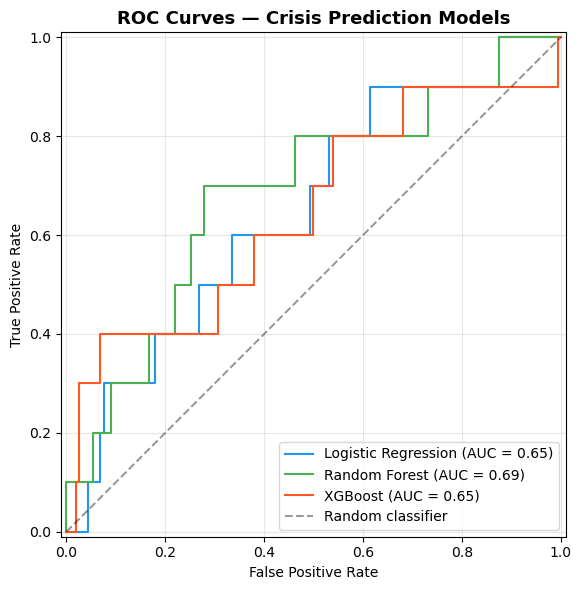

Saved → C:\Users\Owner\OneDrive\dissertation\figures/roc_curves.png


In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#2196F3', '#4CAF50', '#FF5722']
for (name, res), color in zip(results.items(), colors):
    RocCurveDisplay.from_predictions(
        y, res['y_prob'],
        name=name,          # ← removed manual AUC here, display adds it automatically
        ax=ax,
        color=color
    )
ax.plot([0,1],[0,1],'k--', alpha=0.4, label='Random classifier')
ax.set_title('ROC Curves — Crisis Prediction Models', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'roc_curves.png', dpi=150)
plt.show()
print(f'Saved → {FIG_DIR}/roc_curves.png')

## Cell 7 — Feature Importance (Random Forest)

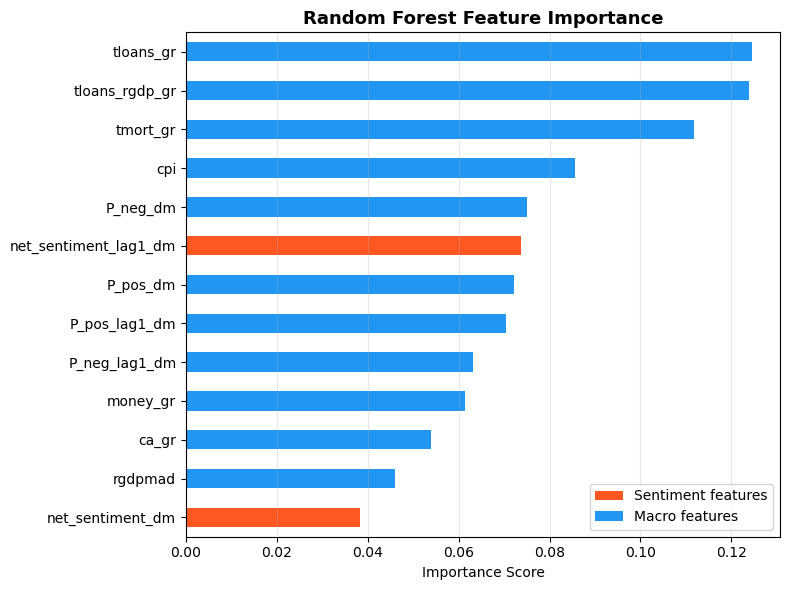

Saved → C:\Users\Owner\OneDrive\dissertation\figures/feature_importance_rf.png


In [17]:
# Fit Random Forest on full data for feature importance
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=5,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X, y)

importances = pd.Series(
    rf_model.feature_importances_,
    index=ALL_FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#FF5722' if 'sentiment' in f or f in sentiment_avail + lag_avail
          else '#2196F3' for f in importances.index]
importances.plot.barh(ax=ax, color=colors)
ax.set_title('Random Forest Feature Importance', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#FF5722', label='Sentiment features'),
    Patch(facecolor='#2196F3', label='Macro features')
]
ax.legend(handles=legend_elements)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(FIG_DIR / 'feature_importance_rf.png', dpi=150)
plt.show()
print(f'Saved → {FIG_DIR}/feature_importance_rf.png')

## Cell 8 — Logistic Regression Coefficients (Interpretability)

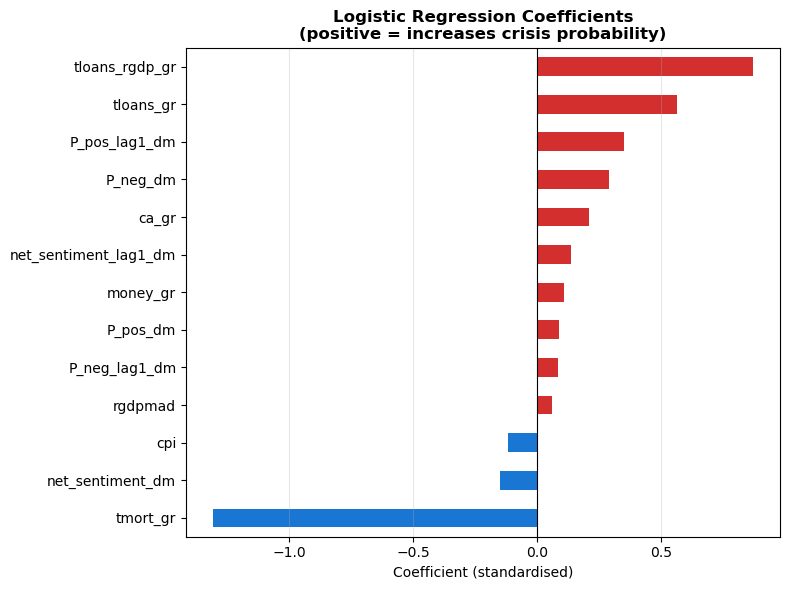

Saved → C:\Users\Owner\OneDrive\dissertation\figures/lr_coefficients.png


In [19]:
# Fit Logistic Regression on full data
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        C=0.1
    ))
])
lr_pipeline.fit(X, y)

coefs = pd.Series(
    lr_pipeline.named_steps['clf'].coef_[0],
    index=ALL_FEATURES
).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#d32f2f' if c > 0 else '#1976D2' for c in coefs]
coefs.plot.barh(ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Coefficients\n(positive = increases crisis probability)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Coefficient (standardised)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(FIG_DIR / 'lr_coefficients.png', dpi=150)
plt.show()
print(f'Saved → {FIG_DIR}/lr_coefficients.png')

## Cell 9 — SHAP Values (XGBoost)

XGBoost fitted.
Model reloaded (base_score fix applied).
SHAP values computed.
Shape: (323, 13)


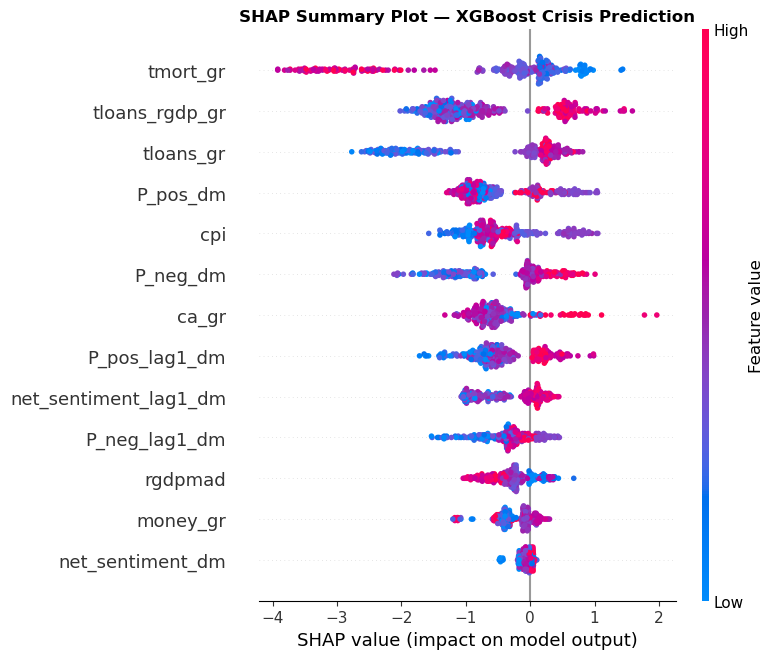

Saved → C:\Users\Owner\OneDrive\dissertation\figures/shap_summary.png


In [21]:
# === CELL 9: SHAP Explanation of XGBoost ===

import tempfile, os

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    base_score=0.5,
    scale_pos_weight=(y==0).sum() / (y==1).sum(),
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X, y)
print('XGBoost fitted.')

# Save and reload to force XGBoost to rewrite base_score in parseable format
tmp = tempfile.mktemp(suffix='.json')
xgb_model.save_model(tmp)
xgb_model.load_model(tmp)
os.remove(tmp)
print('Model reloaded (base_score fix applied).')

# SHAP explanation
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X)
print('SHAP values computed.')
print(f'Shape: {shap_values.shape}')

# Summary plot
plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_values,
    X,
    feature_names=ALL_FEATURES,
    show=False,
    plot_type='dot'
)
plt.title('SHAP Summary Plot — XGBoost Crisis Prediction', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIG_DIR}/shap_summary.png')

## Cell 10 — SHAP Bar Chart (Mean Absolute Impact)

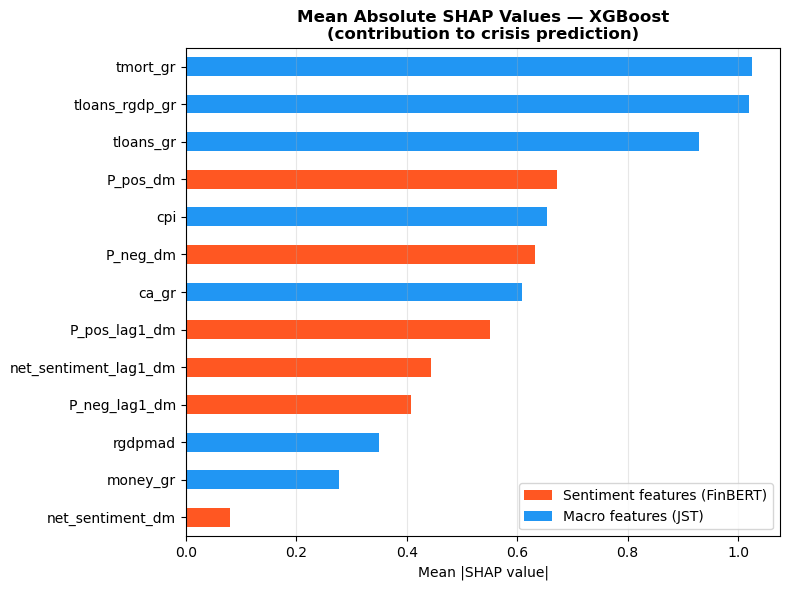

Saved → C:\Users\Owner\OneDrive\dissertation\figures/shap_bar.png


In [25]:
# === CELL 10: SHAP Bar Chart ===

shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=ALL_FEATURES
).sort_values(ascending=True)

# Use engineered sentiment feature names (with _dm suffix)
sentiment_features = SENTIMENT_FEATURES_ENG + LAG_FEATURES_ENG

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#FF5722' if f in sentiment_features else '#2196F3'
          for f in shap_importance.index]

shap_importance.plot.barh(ax=ax, color=colors)
ax.set_title('Mean Absolute SHAP Values — XGBoost\n(contribution to crisis prediction)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Mean |SHAP value|')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#FF5722', label='Sentiment features (FinBERT)'),
    Patch(facecolor='#2196F3', label='Macro features (JST)')
]
ax.legend(handles=legend_elements)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_bar.png', dpi=150)
plt.show()
print(f'Saved → {FIG_DIR}/shap_bar.png')

## Cell 11 — Save Results Summary

In [27]:
# Save model performance results
results_df = pd.DataFrame({
    name: {'AUROC': res['AUROC'], 'AUPRC': res['AUPRC']}
    for name, res in results.items()
}).T

results_df.to_csv(OUT_DIR / 'model_results.csv')
print('Model results saved.')

# Save SHAP values
shap_df = pd.DataFrame(shap_values, columns=ALL_FEATURES)
shap_df.to_csv(OUT_DIR / 'shap_values.csv', index=False)
print('SHAP values saved.')

print()
print('=' * 60)
print(' NOTEBOOK 05 COMPLETE')
print('=' * 60)
print(f'  model_results.csv  → {OUT_DIR}')
print(f'  shap_values.csv    → {OUT_DIR}')
print(f'  Figures            → {FIG_DIR}')
print()
print('Figures generated:')
print('  ✓ roc_curves.png')
print('  ✓ feature_importance_rf.png')
print('  ✓ lr_coefficients.png')
print('  ✓ shap_summary.png')
print('  ✓ shap_bar.png')
print()
print('Ready to proceed to Notebook 06 — Results Analysis & Dissertation Write-up.')

Model results saved.
SHAP values saved.

 NOTEBOOK 05 COMPLETE
  model_results.csv  → C:\Users\Owner\OneDrive\dissertation\data\processed
  shap_values.csv    → C:\Users\Owner\OneDrive\dissertation\data\processed
  Figures            → C:\Users\Owner\OneDrive\dissertation\figures

Figures generated:
  ✓ roc_curves.png
  ✓ feature_importance_rf.png
  ✓ lr_coefficients.png
  ✓ shap_summary.png
  ✓ shap_bar.png

Ready to proceed to Notebook 06 — Results Analysis & Dissertation Write-up.
